# Embeddings Evaluation — MTEB-Style Benchmark

This notebook compares multiple embedding models on a small retrieval benchmark. It demonstrates:
- semantic embeddings and cosine similarity
- Recall@K, Precision@K, MRR@K, and nDCG@K
- embedding latency
- a benchmark report and charts
- an automatic final recommendation

> **Important:** This is an **MTEB-style educational benchmark**, not an official MTEB score. Official MTEB results use standardized datasets and evaluation protocols.

## 1. Install dependencies

Run this cell once in a fresh environment.

In [1]:
!pip install -q sentence-transformers scikit-learn pandas numpy matplotlib

## 2. Imports

In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

pd.set_option('display.max_colwidth', 120)


## 3. Create a small RAG-style benchmark dataset

Each query has one or more **relevant document IDs**. In a real project, create these labels from human annotation or a trusted evaluation set.

In [3]:
documents = [
    {'id': 'D1', 'text': 'Employees can work from home up to three days per week with manager approval.'},
    {'id': 'D2', 'text': 'Employees receive their monthly salary on the last working day of the month.'},
    {'id': 'D3', 'text': 'The company holiday calendar is published on the HR portal every year.'},
    {'id': 'D4', 'text': 'Employees must use the company VPN when accessing internal systems remotely.'},
    {'id': 'D5', 'text': 'Full-time employees are eligible for the company health insurance plan.'},
    {'id': 'D6', 'text': 'Managers should approve remote work requests according to team requirements.'},
    {'id': 'D7', 'text': 'Employees can request annual leave through the HR management system.'},
    {'id': 'D8', 'text': 'The IT department provides laptops and technical support to employees.'},
    {'id': 'D9', 'text': 'Remote employees should follow all company cybersecurity and data protection policies.'},
    {'id': 'D10', 'text': 'New employees complete an onboarding program during their first week.'},
]

queries = [
    {'query': 'What is the work from home policy?', 'relevant': ['D1', 'D6']},
    {'query': 'When do employees get their salary?', 'relevant': ['D2']},
    {'query': 'Where can I find the company holiday schedule?', 'relevant': ['D3']},
    {'query': 'What security requirement applies when working remotely?', 'relevant': ['D4', 'D9']},
    {'query': 'Who is eligible for health insurance?', 'relevant': ['D5']},
    {'query': 'How do I request annual leave?', 'relevant': ['D7']},
    {'query': 'Does the company provide laptops?', 'relevant': ['D8']},
    {'query': 'What happens during employee onboarding?', 'relevant': ['D10']},
]

documents_df = pd.DataFrame(documents)
queries_df = pd.DataFrame(queries)

print(f'Documents: {len(documents)}')
print(f'Queries: {len(queries)}')
queries_df

Documents: 10
Queries: 8


,query,relevant
0,What is the work from home policy?,"[D1, D6]"
1,When do employees get their salary?,[D2]
2,Where can I find the company holiday schedule?,[D3]
3,What security requirement applies when working remotely?,"[D4, D9]"
4,Who is eligible for health insurance?,[D5]
5,How do I request annual leave?,[D7]
6,Does the company provide laptops?,[D8]
7,What happens during employee onboarding?,[D10]


## 4. Choose embedding models

The notebook uses two lightweight Sentence Transformers models by default. You can add more models later.

**Tip:** The first run downloads the models from Hugging Face, so model loading requires internet access.

In [4]:
MODEL_NAMES = {
    'MiniLM': 'sentence-transformers/all-MiniLM-L6-v2',
    'MPNet': 'sentence-transformers/all-mpnet-base-v2',
}

MODELS = {}
for name, model_name in MODEL_NAMES.items():
    print(f'Loading {name}: {model_name}')
    MODELS[name] = SentenceTransformer(model_name)
    print('Loaded.')

Loading MiniLM: sentence-transformers/all-MiniLM-L6-v2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loaded.


## 5. Understand cosine similarity

Cosine similarity measures the angle between two vectors. Higher values mean the vectors point in more similar directions.

$$\text{cosine}(A,B)=\frac{A\cdot B}{||A||\,||B||}$$

For retrieval, we embed the query and documents, calculate similarities, and rank documents from highest to lowest.

In [5]:
sample_model = MODELS['MiniLM']
sample_texts = [
    'How can I reset my password?',
    'I forgot my password and need to change it.',
    'How do I cook pasta?'
]

sample_embeddings = sample_model.encode(sample_texts, normalize_embeddings=True)
sample_scores = cosine_similarity(sample_embeddings)

pd.DataFrame(sample_scores, index=['Password reset', 'Forgot password', 'Cooking pasta'],
             columns=['Password reset', 'Forgot password', 'Cooking pasta']).round(3)

,Password reset,Forgot password,Cooking pasta
Password reset,1.000,0.824,0.151
Forgot password,0.824,1.000,0.102
Cooking pasta,0.151,0.102,1.000


## 6. Define evaluation metrics

- **Precision@K:** fraction of the top-K retrieved documents that are relevant.
- **Recall@K:** fraction of all relevant documents found in the top-K.
- **MRR@K:** reciprocal rank of the first relevant document.
- **nDCG@K:** ranking-quality metric that rewards relevant documents appearing near the top.

In [6]:
def precision_at_k(ranked_ids, relevant_ids, k):
    top_k = ranked_ids[:k]
    return sum(doc_id in relevant_ids for doc_id in top_k) / k


def recall_at_k(ranked_ids, relevant_ids, k):
    if not relevant_ids:
        return 0.0
    top_k = ranked_ids[:k]
    return sum(doc_id in relevant_ids for doc_id in top_k) / len(relevant_ids)


def mrr_at_k(ranked_ids, relevant_ids, k):
    for rank, doc_id in enumerate(ranked_ids[:k], start=1):
        if doc_id in relevant_ids:
            return 1.0 / rank
    return 0.0


def dcg_at_k(relevances, k):
    relevances = np.asarray(relevances[:k], dtype=float)
    if len(relevances) == 0:
        return 0.0
    discounts = np.log2(np.arange(2, len(relevances) + 2))
    return np.sum((2 ** relevances - 1) / discounts)


def ndcg_at_k(ranked_ids, relevant_ids, k):
    # Binary relevance: 1 = relevant, 0 = not relevant.
    actual = [1 if doc_id in relevant_ids else 0 for doc_id in ranked_ids]
    ideal = sorted(actual, reverse=True)
    ideal_dcg = dcg_at_k(ideal, k)
    if ideal_dcg == 0:
        return 0.0
    return dcg_at_k(actual, k) / ideal_dcg

## 7. Run the retrieval benchmark

We use the **same documents and queries for every model** so the comparison is fair.

In [7]:
document_ids = documents_df['id'].tolist()
document_texts = documents_df['text'].tolist()
query_texts = queries_df['query'].tolist()

K_VALUES = [1, 3, 5, 10]
benchmark_rows = []
ranking_rows = []

for model_name, model in MODELS.items():
    start = time.perf_counter()
    doc_embeddings = model.encode(
        document_texts,
        normalize_embeddings=True,
        show_progress_bar=False
    )
    doc_time = time.perf_counter() - start

    start = time.perf_counter()
    query_embeddings = model.encode(
        query_texts,
        normalize_embeddings=True,
        show_progress_bar=False
    )
    query_time = time.perf_counter() - start

    similarity_matrix = cosine_similarity(query_embeddings, doc_embeddings)

    for i, row in queries_df.iterrows():
        scores = similarity_matrix[i]
        order = np.argsort(-scores)
        ranked_ids = [document_ids[j] for j in order]
        ranked_scores = [float(scores[j]) for j in order]
        relevant_ids = set(row['relevant'])

        ranking_rows.append({
            'model': model_name,
            'query': row['query'],
            'top_5': ranked_ids[:5],
            'top_5_scores': [round(x, 4) for x in ranked_scores[:5]]
        })

        for k in K_VALUES:
            benchmark_rows.append({
                'model': model_name,
                'k': k,
                'precision': precision_at_k(ranked_ids, relevant_ids, k),
                'recall': recall_at_k(ranked_ids, relevant_ids, k),
                'mrr': mrr_at_k(ranked_ids, relevant_ids, k),
                'ndcg': ndcg_at_k(ranked_ids, relevant_ids, k),
            })

    benchmark_rows[-1]['doc_embedding_seconds'] = doc_time
    benchmark_rows[-1]['query_embedding_seconds'] = query_time

benchmark_df = pd.DataFrame(benchmark_rows)
ranking_df = pd.DataFrame(ranking_rows)

# Latency is model-level, so calculate it separately.
latency_rows = []
for model_name, model in MODELS.items():
    start = time.perf_counter()
    _ = model.encode(document_texts, normalize_embeddings=True, show_progress_bar=False)
    doc_seconds = time.perf_counter() - start
    start = time.perf_counter()
    _ = model.encode(query_texts, normalize_embeddings=True, show_progress_bar=False)
    query_seconds = time.perf_counter() - start
    latency_rows.append({
        'model': model_name,
        'embedding_dimension': MODELS[model_name].get_sentence_embedding_dimension(),
        'document_embedding_seconds': doc_seconds,
        'query_embedding_seconds': query_seconds,
        'documents_per_second': len(document_texts) / doc_seconds,
        'queries_per_second': len(query_texts) / query_seconds,
    })

latency_df = pd.DataFrame(latency_rows)
benchmark_df.head()

/tmp/ipykernel_836/3956189013.py:69: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  'embedding_dimension': MODELS[model_name].get_sentence_embedding_dimension(),


,model,k,precision,recall,mrr,ndcg,doc_embedding_seconds,query_embedding_seconds
0,MiniLM,1,1.000000,0.5,1.0,1.000000,NaN,NaN
1,MiniLM,3,0.666667,1.0,1.0,0.919721,NaN,NaN
2,MiniLM,5,0.400000,1.0,1.0,0.919721,NaN,NaN
3,MiniLM,10,0.200000,1.0,1.0,0.919721,NaN,NaN
4,MiniLM,1,1.000000,1.0,1.0,1.000000,NaN,NaN


## 8. Aggregate benchmark report

For RAG, **Recall@5, MRR@5, and nDCG@5** are particularly useful because they tell us whether relevant context is being retrieved and how high it appears in the ranking.

In [8]:
report = (
    benchmark_df[benchmark_df['k'] == 5]
    .groupby('model')[['precision', 'recall', 'mrr', 'ndcg']]
    .mean()
    .rename(columns={
        'precision': 'Precision@5',
        'recall': 'Recall@5',
        'mrr': 'MRR@5',
        'ndcg': 'nDCG@5'
    })
    .join(latency_df.set_index('model')[['embedding_dimension', 'queries_per_second']])
)

report['Accuracy Score'] = (
    0.40 * report['Recall@5'] +
    0.30 * report['MRR@5'] +
    0.30 * report['nDCG@5']
)

report = report.sort_values('Accuracy Score', ascending=False)
report.style.format({
    'Precision@5': '{:.2%}',
    'Recall@5': '{:.2%}',
    'MRR@5': '{:.3f}',
    'nDCG@5': '{:.3f}',
    'Accuracy Score': '{:.3f}',
    'queries_per_second': '{:.2f}'
})

,Precision@5,Recall@5,MRR@5,nDCG@5,embedding_dimension,queries_per_second,Accuracy Score
model,,,,,,,
MiniLM,25.00%,100.00%,1.000,0.990,384,983.28,0.997
MPNet,22.50%,93.75%,1.000,0.942,768,452.11,0.957


## 9. View example rankings

This is useful for debugging. Metrics tell you **how much** a model succeeds; rankings help you understand **why**.

In [9]:
ranking_df

,model,query,top_5,top_5_scores
0,MiniLM,What is the work from home policy?,"[D1, D5, D6, D4, D9]","[0.5913, 0.3794, 0.3633, 0.3089, 0.3007]"
1,MiniLM,When do employees get their salary?,"[D2, D1, D7, D3, D5]","[0.6323, 0.3757, 0.3634, 0.3368, 0.332]"
2,MiniLM,Where can I find the company holiday schedule?,"[D3, D2, D1, D7, D10]","[0.7581, 0.3883, 0.34, 0.3088, 0.261]"
3,MiniLM,What security requirement applies when working remotely?,"[D4, D9, D6, D1, D8]","[0.5996, 0.5538, 0.5187, 0.3, 0.2544]"
4,MiniLM,Who is eligible for health insurance?,"[D5, D8, D10, D7, D9]","[0.587, 0.1366, 0.1113, 0.1045, 0.0913]"
5,MiniLM,How do I request annual leave?,"[D7, D3, D2, D5, D1]","[0.7221, 0.3679, 0.3435, 0.2908, 0.2776]"
6,MiniLM,Does the company provide laptops?,"[D8, D4, D5, D6, D9]","[0.6547, 0.2963, 0.2522, 0.214, 0.2071]"
7,MiniLM,What happens during employee onboarding?,"[D10, D8, D7, D4, D1]","[0.6557, 0.3203, 0.314, 0.2795, 0.2672]"
8,MPNet,What is the work from home policy?,"[D1, D5, D7, D8, D9]","[0.4866, 0.381, 0.3425, 0.2633, 0.2482]"
9,MPNet,When do employees get their salary?,"[D2, D10, D3, D7, D5]","[0.6711, 0.3674, 0.36, 0.3546, 0.2967]"


## 10. Plot Recall@K

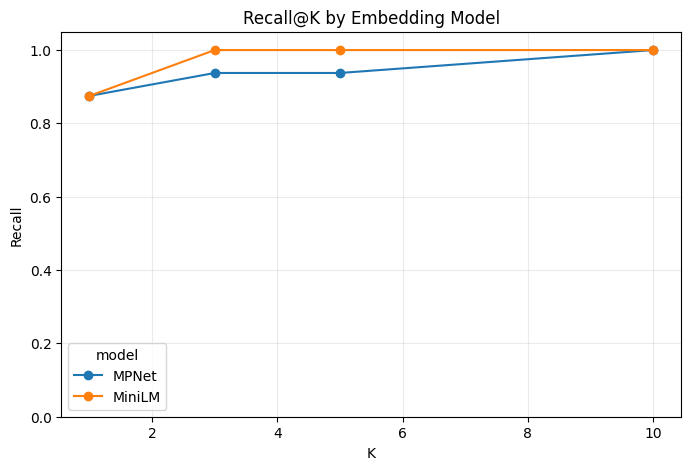

In [12]:
# Aggregate results across all queries
recall_plot = (
    benchmark_df
    .groupby(['k', 'model'])['recall']
    .mean()
    .unstack('model')
)

ax = recall_plot.plot(
    marker='o',
    figsize=(8, 5)
)

ax.set_title('Recall@K by Embedding Model')
ax.set_xlabel('K')
ax.set_ylabel('Recall')
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.25)

plt.show()
# recall_plot = benchmark_df.pivot(index='k', columns='model', values='recall')
# ax = recall_plot.plot(marker='o', figsize=(8, 5))
# ax.set_title('Recall@K by Embedding Model')
# ax.set_xlabel('K')
# ax.set_ylabel('Recall')
# ax.set_ylim(0, 1.05)
# ax.grid(True, alpha=0.25)
# plt.show()

## 11. Plot MRR@K

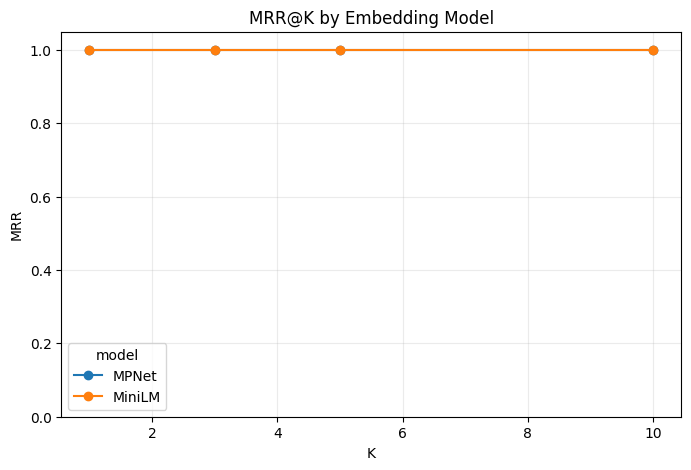

In [13]:
# Aggregate results across all queries
mrr_plot = (
    benchmark_df
    .groupby(['k', 'model'])['mrr']
    .mean()
    .unstack('model')
)

ax = mrr_plot.plot(
    marker='o',
    figsize=(8, 5)
)

ax.set_title('MRR@K by Embedding Model')
ax.set_xlabel('K')
ax.set_ylabel('MRR')
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.25)

plt.show()

## 12. Compare retrieval metrics at K=5

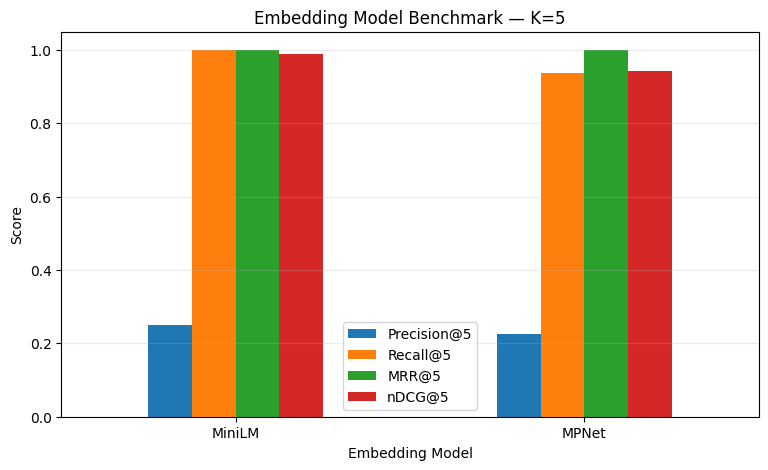

In [14]:
metrics_for_plot = report[['Precision@5', 'Recall@5', 'MRR@5', 'nDCG@5']]
ax = metrics_for_plot.plot(kind='bar', figsize=(9, 5))
ax.set_title('Embedding Model Benchmark — K=5')
ax.set_xlabel('Embedding Model')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.grid(True, axis='y', alpha=0.25)
plt.xticks(rotation=0)
plt.show()

## 13. Generate a benchmark report automatically

In [15]:
best_model = report.index[0]
best_row = report.iloc[0]

print('=' * 70)
print('EMBEDDINGS BENCHMARK REPORT')
print('=' * 70)
print(f'Dataset: {len(documents)} documents, {len(queries)} queries')
print('Evaluation: Retrieval benchmark, K=5')
print('')
print(report[['Precision@5', 'Recall@5', 'MRR@5', 'nDCG@5', 'Accuracy Score']].round(4))
print('')
print(f'Recommended model: {best_model}')
print(f"Reason: highest weighted retrieval score ({best_row['Accuracy Score']:.3f})")
print('')
print('NOTE: The weighted Accuracy Score is a project-specific ranking score, not an official MTEB metric.')

EMBEDDINGS BENCHMARK REPORT
Dataset: 10 documents, 8 queries
Evaluation: Retrieval benchmark, K=5

        Precision@5  Recall@5  MRR@5  nDCG@5  Accuracy Score
model                                                       
MiniLM        0.250    1.0000    1.0  0.9900          0.9970
MPNet         0.225    0.9375    1.0  0.9416          0.9575

Recommended model: MiniLM
Reason: highest weighted retrieval score (0.997)

NOTE: The weighted Accuracy Score is a project-specific ranking score, not an official MTEB metric.


## 14. Export the benchmark report

The CSV can be attached to a project report or used for comparing future models.

In [16]:
report.to_csv('embedding_benchmark_report.csv')
ranking_df.to_csv('embedding_rankings.csv', index=False)

print('Saved: embedding_benchmark_report.csv')
print('Saved: embedding_rankings.csv')

Saved: embedding_benchmark_report.csv
Saved: embedding_rankings.csv


In [17]:
report = (
    benchmark_df[benchmark_df['k'] == 5]
    .groupby('model')[['precision', 'recall', 'mrr', 'ndcg']]
    .mean()
    .rename(columns={
        'precision': 'Precision@5',
        'recall': 'Recall@5',
        'mrr': 'MRR@5',
        'ndcg': 'nDCG@5'
    })
)

report['Accuracy Score'] = (
    0.40 * report['Recall@5'] +
    0.30 * report['MRR@5'] +
    0.30 * report['nDCG@5']
)

report = report.sort_values(
    'Accuracy Score',
    ascending=False
)

report

,Precision@5,Recall@5,MRR@5,nDCG@5,Accuracy Score
model,,,,,
MiniLM,0.250,1.0000,1.0,0.989965,0.996990
MPNet,0.225,0.9375,1.0,0.941608,0.957483
